In [1]:
import pandas as pd
import os
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("../03_Data/Original Data/OnlineRetail.csv", encoding="latin-1")


# EDA

In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%m/%d/%Y %H:%M")
df["CustomerID"] = df["CustomerID"].astype("Int32")  # nullable integer


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.0
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.69057
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.0
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.0
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.0
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.0
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.0
std,218.081158,NaN,96.759853,1713.600303


In [6]:
df.describe(include=object)

,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


In [7]:
df.shape

(541909, 8)

## Missing values 

In [8]:
# Missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df.isnull().mean() * 100  # as percentage

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

## Duplicates

In [10]:
df.duplicated(subset=['InvoiceNo', 'StockCode']).sum()

np.int64(10684)

In [11]:
print(df.duplicated().sum())

5268


In [12]:
# Inspect an example of a key-only duplicate
dup_key = df[df.duplicated(subset=['InvoiceNo', 'StockCode'], keep=False)]

In [13]:
dup_key.sort_values(['InvoiceNo', 'StockCode']).head(10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
113,536381,71270,PHOTO CLIP LINE,1,2010-12-01 09:41:00,1.25,15311,United Kingdom
125,536381,71270,PHOTO CLIP LINE,3,2010-12-01 09:41:00,1.25,15311,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908,United Kingdom


### Drop duplicates

So we have two distinct problems:

5,268 exact full-row duplicates — safe to drop, these are true data pipeline duplicates
10,684 − 5,268 = 5,416 rows where InvoiceNo + StockCode repeats but with different values (Quantity, UnitPrice, etc.)
The second group needs investigation before we touch them:

In [14]:
# Look at the non-exact duplicates (same key, different values)
exact_dups = df.duplicated(keep=False)
key_dups = df.duplicated(subset=['InvoiceNo', 'StockCode'], keep=False)

In [15]:
mixed = df[key_dups & ~exact_dups]
mixed.sort_values(['InvoiceNo', 'StockCode']).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
113,536381,71270,PHOTO CLIP LINE,1,2010-12-01 09:41:00,1.25,15311,United Kingdom
125,536381,71270,PHOTO CLIP LINE,3,2010-12-01 09:41:00,1.25,15311,United Kingdom
491,536409,85116,BLACK CANDELABRA T-LIGHT HOLDER,1,2010-12-01 11:45:00,2.10,17908,United Kingdom
502,536409,85116,BLACK CANDELABRA T-LIGHT HOLDER,5,2010-12-01 11:45:00,2.10,17908,United Kingdom
483,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,3,2010-12-01 11:45:00,6.35,17908,United Kingdom
498,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,1,2010-12-01 11:45:00,6.35,17908,United Kingdom
525,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,2,2010-12-01 11:45:00,6.35,17908,United Kingdom
561,536412,21738,COSY SLIPPER SHOES SMALL RED,1,2010-12-01 11:49:00,2.95,17920,United Kingdom
571,536412,21738,COSY SLIPPER SHOES SMALL RED,2,2010-12-01 11:49:00,2.95,17920,United Kingdom
585,536412,21738,COSY SLIPPER SHOES SMALL RED,5,2010-12-01 11:49:00,2.95,17920,United Kingdom


### Handling Strategy

| Type | Count | Root cause | Fix |
|---|---|---|---|
| Exact full-row duplicates | 5,268 | Pipeline re-ingestion | `drop_duplicates()` |
| Same `InvoiceNo+StockCode`, different `Quantity` | 5,416 rows → ~2,700 groups | Split line items (same item added in multiple qty entries) | Aggregate: `sum(Quantity)` |

In [16]:
df_clean = df.drop_duplicates()  # drop 5,268 exact copies
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]:,}")
print(f"Rows remaining: {df_clean.shape[0]:,}")

Rows removed: 5,268
Rows remaining: 536,641


In [17]:
GROUP_KEYS = ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

df_clean = (
    df_clean
    .groupby(GROUP_KEYS, as_index=False, dropna=False)  # dropna=False keeps null CustomerID rows
    .agg({'Quantity': 'sum'})                            # sum split qty entries into one line
)

print(f"Rows removed: {536641 - df_clean.shape[0]:,}")
print(f"Rows remaining: {df_clean.shape[0]:,}")

Rows removed: 4,833
Rows remaining: 531,808


In [18]:
# Diagnose: what column differs in the remaining key duplicates?
still_dup = df_clean[df_clean.duplicated(subset=['InvoiceNo', 'StockCode'], keep=False)]
print(f"Remaining key duplicate rows: {len(still_dup)}")
still_dup.sort_values(['InvoiceNo', 'StockCode']).head(12)

Remaining key duplicate rows: 1118


,InvoiceNo,StockCode,Description,InvoiceDate,UnitPrice,CustomerID,Country,Quantity
1433,536544,21218,RED SPOTTY BISCUIT TIN,2010-12-01 14:32:00,3.75,<NA>,United Kingdom,2
1434,536544,21218,RED SPOTTY BISCUIT TIN,2010-12-01 14:32:00,8.47,<NA>,United Kingdom,1
1714,536544,22844,VINTAGE CREAM DOG FOOD CONTAINER,2010-12-01 14:32:00,8.50,<NA>,United Kingdom,2
1715,536544,22844,VINTAGE CREAM DOG FOOD CONTAINER,2010-12-01 14:32:00,16.98,<NA>,United Kingdom,1
1718,536544,22862,LOVE HEART NAPKIN BOX,2010-12-01 14:32:00,4.25,<NA>,United Kingdom,2
1719,536544,22862,LOVE HEART NAPKIN BOX,2010-12-01 14:32:00,8.47,<NA>,United Kingdom,1
1721,536544,22866,HAND WARMER SCOTTY DOG DESIGN,2010-12-01 14:32:00,2.10,<NA>,United Kingdom,3
1722,536544,22866,HAND WARMER SCOTTY DOG DESIGN,2010-12-01 14:32:00,4.21,<NA>,United Kingdom,4
2132,536569,M,Manual,2010-12-01 15:35:00,1.25,16274,United Kingdom,1
2133,536569,M,Manual,2010-12-01 15:35:00,18.95,16274,United Kingdom,1


## Customer Segmentation: B2C vs B2B

Wholesalers (B2B) place high-volume repeat orders; retail buyers (B2C) buy small quantities for personal use.

| Segment | Criterion | Churn window |
|---|---|---|
| B2B | Mean order qty > 20 units | 60 days |
| B2C | Mean order qty ≤ 20 units | 90 days |

In [19]:
sales = df_clean[
    (df_clean['Quantity'] > 0) &          # exclude cancellations
    (df_clean['CustomerID'].notna())       # exclude anonymous transactions
]

customer_stats = (
    sales
    .groupby('CustomerID')
    .agg(
        mean_qty=('Quantity', 'mean'),     # avg units per line item
        order_count=('InvoiceNo', 'nunique')
    )
)

customer_stats['CustomerType'] = customer_stats['mean_qty'].apply(
    lambda x: 'B2B' if x > 20 else 'B2C'
)

print(customer_stats['CustomerType'].value_counts())
print(f"\nB2B share: {(customer_stats['CustomerType']=='B2B').mean():.1%}")

CustomerType
B2C    3686
B2B     653
Name: count, dtype: int64

B2B share: 15.0%


In [20]:
# Merge customer type back into the main dataframe
df_clean = df_clean.merge(
    customer_stats[['CustomerType']],
    on='CustomerID',
    how='left'                             # anonymous rows get NaN CustomerType
)

df_clean['CustomerType'].value_counts(dropna=False)

CustomerType
B2C    357855
NaN    135074
B2B     38879
Name: count, dtype: int64

## Data Quality
Remove noise before analysis: cancellations (Quantity < 0), non-product entries (AMAZONFEE, manual adjustments), and records with zero or negative UnitPrice.

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Non-product StockCodes: fees, manual adjustments, bank charges, postage
NON_PRODUCT = {'AMAZONFEE', 'B', 'M', 'S', 'BANK CHARGES', 'POST', 'D', 'DOT'}

sales = df_clean[
    (df_clean['Quantity'] > 0) &                                   # drop returns / cancellations
    (df_clean['UnitPrice'] > 0) &                                  # drop zero/negative prices
    (~df_clean['StockCode'].isin(NON_PRODUCT)) &                   # drop fee/adjustment rows
    (~df_clean['StockCode'].str.startswith('C', na=False))         # drop credit-note codes
].copy()

print(f"df_clean rows:         {len(df_clean):,}")
print(f"sales rows (clean):    {len(sales):,}")
print(f"Rows removed:          {len(df_clean) - len(sales):,}")

df_clean rows:         531,808
sales rows (clean):    517,778
Rows removed:          14,030


## Revenue Analysis
`Revenue = Quantity × UnitPrice` — the core business metric.  
B2B customers are only 15% of customers but likely drive a disproportionate share of revenue.

In [22]:
# Revenue = Quantity × UnitPrice
sales['Revenue'] = sales['Quantity'] * sales['UnitPrice']

total_revenue = sales['Revenue'].sum()
print(f"Total revenue:         £{total_revenue:,.0f}")
print(f"Avg line item value:   £{sales['Revenue'].mean():.2f}")
print(f"Median line item value:£{sales['Revenue'].median():.2f}\n")

# B2B vs B2C revenue breakdown (identified customers only)
rev_by_type = (
    sales[sales['CustomerType'].notna()]
    .groupby('CustomerType')['Revenue']
    .agg(Total='sum', AvgLine='mean', Lines='count')
)
rev_by_type['Share %'] = (rev_by_type['Total'] / rev_by_type['Total'].sum() * 100).round(1)
rev_by_type['Total']   = rev_by_type['Total'].map('£{:,.0f}'.format)
rev_by_type['AvgLine'] = rev_by_type['AvgLine'].map('£{:.2f}'.format)
rev_by_type

Total revenue:         £10,247,908
Avg line item value:   £19.79
Median line item value:£9.95



,Total,AvgLine,Lines,Share %
CustomerType,,,,
B2B,"£3,691,869",£99.50,37105,42.3
B2C,"£5,045,359",£14.44,349298,57.7


## Time Trends
Monthly revenue to reveal seasonality — gift retail typically peaks in Q4.

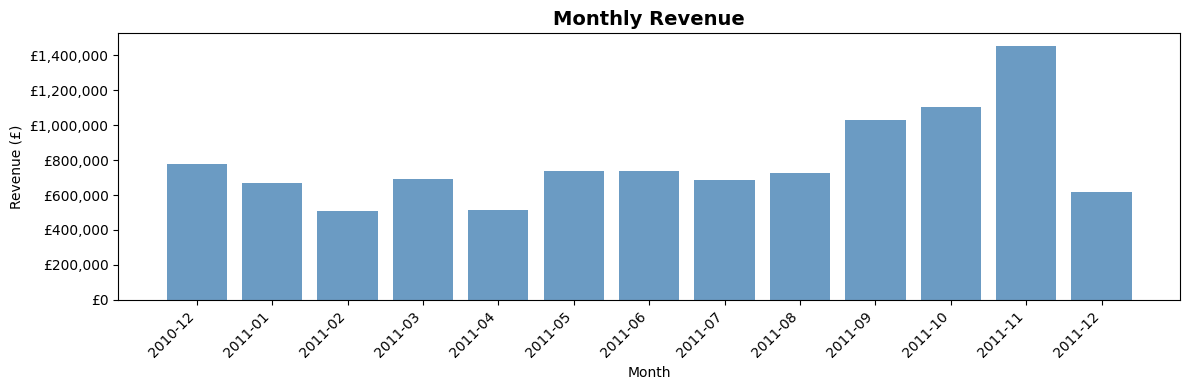

Peak month: 2011-11  £1,452,116


In [23]:
# group revenue by calendar month
sales['YearMonth'] = sales['InvoiceDate'].dt.to_period('M')

monthly = (
    sales.groupby('YearMonth')['Revenue']
    .sum()
    .reset_index()
)
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly['YearMonth'], monthly['Revenue'], color='steelblue', alpha=0.8)
ax.set_title('Monthly Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# peak month
peak = monthly.loc[monthly['Revenue'].idxmax()]
print(f"Peak month: {peak['YearMonth']}  £{peak['Revenue']:,.0f}")

## Geography
Revenue distribution across countries. The UK dominates but there is meaningful international volume.

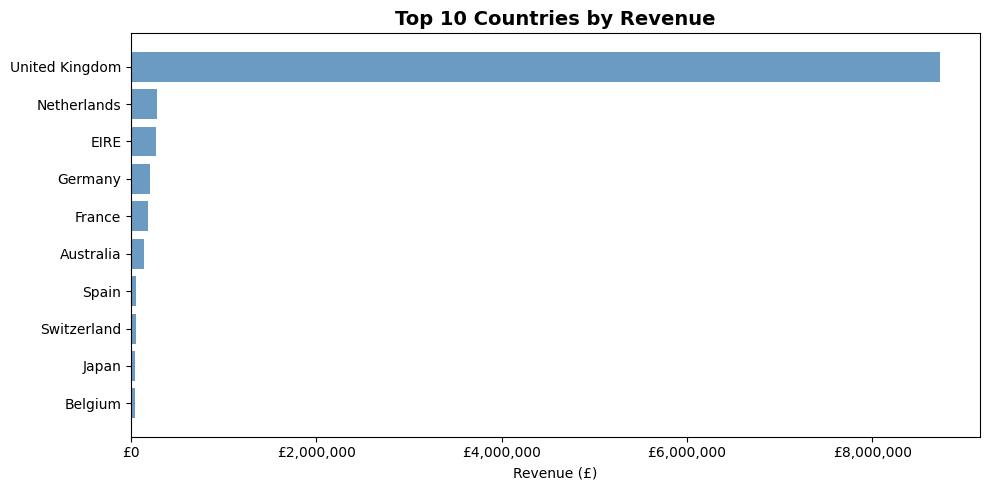

UK revenue:            £8,725,132  (85.1%)
International revenue: £1,522,776  (14.9%)


In [24]:
# top 10 countries by revenue
top_countries = (
    sales.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_countries['Country'][::-1], top_countries['Revenue'][::-1], color='steelblue', alpha=0.8)
ax.set_title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

# UK vs international revenue split
uk_rev  = sales[sales['Country'] == 'United Kingdom']['Revenue'].sum()
intl_rev = sales[sales['Country'] != 'United Kingdom']['Revenue'].sum()
print(f"UK revenue:            £{uk_rev:,.0f}  ({uk_rev/total_revenue:.1%})")
print(f"International revenue: £{intl_rev:,.0f}  ({intl_rev/total_revenue:.1%})")

## Product Analysis
Top-performing products by revenue and by units sold.

In [25]:
# top 10 products by revenue
top_by_rev = (
    sales.groupby(['StockCode', 'Description'])
    .agg(Revenue=('Revenue', 'sum'), UnitsSold=('Quantity', 'sum'))
    .sort_values('Revenue', ascending=False)
    .head(10)
    .reset_index()
)
top_by_rev['Revenue'] = top_by_rev['Revenue'].map('£{:,.0f}'.format)
print("── Top 10 by Revenue ──")
print(top_by_rev[['Description', 'Revenue', 'UnitsSold']].to_string(index=False))

print()

# top 10 products by units sold
top_by_qty = (
    sales.groupby(['StockCode', 'Description'])
    .agg(UnitsSold=('Quantity', 'sum'), Revenue=('Revenue', 'sum'))
    .sort_values('UnitsSold', ascending=False)
    .head(10)
    .reset_index()
)
top_by_qty['Revenue'] = top_by_qty['Revenue'].map('£{:,.0f}'.format)
print("── Top 10 by Units Sold ──")
print(top_by_qty[['Description', 'UnitsSold', 'Revenue']].to_string(index=False))

── Top 10 by Revenue ──
                       Description  Revenue  UnitsSold
          REGENCY CAKESTAND 3 TIER £174,157      13851
       PAPER CRAFT , LITTLE BIRDIE £168,470      80995
WHITE HANGING HEART T-LIGHT HOLDER £104,284      37580
                     PARTY BUNTING  £99,445      18283
           JUMBO BAG RED RETROSPOT  £94,160      48371
    MEDIUM CERAMIC TOP STORAGE JAR  £81,701      78033
                RABBIT NIGHT LIGHT  £66,870      30739
   PAPER CHAIN KIT 50'S CHRISTMAS   £64,876      19329
     ASSORTED COLOUR BIRD ORNAMENT  £58,928      36362
                     CHILLI LIGHTS  £54,096      10302

── Top 10 by Units Sold ──
                       Description  UnitsSold  Revenue
       PAPER CRAFT , LITTLE BIRDIE      80995 £168,470
    MEDIUM CERAMIC TOP STORAGE JAR      78033  £81,701
 WORLD WAR 2 GLIDERS ASSTD DESIGNS      54951  £13,814
           JUMBO BAG RED RETROSPOT      48371  £94,160
WHITE HANGING HEART T-LIGHT HOLDER      37580 £104,284
             

## Dashboard Visualisations (Plotly)
Interactive charts built with Plotly — ready to drop into a Streamlit dashboard via `st.plotly_chart(fig)`.

In [26]:
import plotly.express as px

# ── Monthly revenue trend ─────────────────────────────────────────────────────
monthly_plotly = (
    sales.groupby('YearMonth')['Revenue']
    .sum()
    .reset_index()
)
monthly_plotly['YearMonth'] = monthly_plotly['YearMonth'].astype(str)

fig_monthly = px.bar(
    monthly_plotly,
    x='YearMonth',
    y='Revenue',
    title='Monthly Revenue',
    labels={'YearMonth': 'Month', 'Revenue': 'Revenue (£)'},
    text='Revenue',
    color='Revenue',
    color_continuous_scale='Blues',
)
fig_monthly.update_traces(texttemplate='£%{text:,.0f}', textposition='outside')
fig_monthly.update_layout(
    xaxis_tickangle=-45,
    coloraxis_showscale=False,
    plot_bgcolor='white',
    margin=dict(t=60, b=80),
    height=450,
)
fig_monthly.show()

In [27]:
# ── B2B vs B2C — revenue and avg line value side by side ─────────────────────
seg = (
    sales[sales['CustomerType'].notna()]
    .groupby('CustomerType')
    .agg(
        TotalRevenue=('Revenue', 'sum'),
        AvgLineValue=('Revenue', 'mean'),
    )
    .reset_index()
)

# total revenue by segment
fig_seg_total = px.bar(
    seg,
    x='CustomerType',
    y='TotalRevenue',
    title='Total Revenue by Segment',
    labels={'TotalRevenue': 'Revenue (£)', 'CustomerType': ''},
    color='CustomerType',
    color_discrete_map={'B2B': '#1f77b4', 'B2C': '#aec7e8'},
    text='TotalRevenue',
)
fig_seg_total.update_traces(texttemplate='£%{text:,.0f}', textposition='outside')
fig_seg_total.update_layout(showlegend=False, plot_bgcolor='white', height=380)
fig_seg_total.show()

# avg line item value by segment — shows B2B orders are much larger per line
fig_seg_avg = px.bar(
    seg,
    x='CustomerType',
    y='AvgLineValue',
    title='Avg Line Item Value by Segment',
    labels={'AvgLineValue': 'Avg Revenue per Line (£)', 'CustomerType': ''},
    color='CustomerType',
    color_discrete_map={'B2B': '#1f77b4', 'B2C': '#aec7e8'},
    text='AvgLineValue',
)
fig_seg_avg.update_traces(texttemplate='£%{text:.2f}', textposition='outside')
fig_seg_avg.update_layout(showlegend=False, plot_bgcolor='white', height=380)
fig_seg_avg.show()

In [28]:
# ── Top 10 countries by revenue ──────────────────────────────────────────────
top_geo = (
    sales.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .sort_values('Revenue')                    # ascending for horizontal bar readability
)

fig_geo = px.bar(
    top_geo,
    x='Revenue',
    y='Country',
    orientation='h',
    title='Top 10 Countries by Revenue',
    labels={'Revenue': 'Revenue (£)', 'Country': ''},
    color='Revenue',
    color_continuous_scale='Blues',
    text='Revenue',
)
fig_geo.update_traces(texttemplate='£%{text:,.0f}', textposition='outside')
fig_geo.update_layout(
    coloraxis_showscale=False,
    plot_bgcolor='white',
    margin=dict(l=0, r=80, t=50, b=0),
    height=420,
)
fig_geo.show()

In [29]:
# ── Top 10 products by revenue ───────────────────────────────────────────────
top_rev_prod = (
    sales.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .sort_values('Revenue')                    # ascending for horizontal bar readability
)

fig_prod = px.bar(
    top_rev_prod,
    x='Revenue',
    y='Description',
    orientation='h',
    title='Top 10 Products by Revenue',
    labels={'Revenue': 'Revenue (£)', 'Description': ''},
    color='Revenue',
    color_continuous_scale='Blues',
    text='Revenue',
)
fig_prod.update_traces(texttemplate='£%{text:,.0f}', textposition='outside')
fig_prod.update_layout(
    coloraxis_showscale=False,
    plot_bgcolor='white',
    margin=dict(l=0, r=80, t=50, b=0),
    height=420,
)
fig_prod.show()

In [30]:
# ── Top 10 products by units sold ───────────────────────────────────────────
top_qty = (
    sales.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .sort_values('Quantity')                   # ascending for horizontal bar readability
)

fig_qty = px.bar(
    top_qty,
    x='Quantity',
    y='Description',
    orientation='h',
    title='Top 10 Products by Units Sold',
    labels={'Quantity': 'Units Sold', 'Description': ''},
    color='Quantity',
    color_continuous_scale='Blues',
    text='Quantity',
)
fig_qty.update_traces(texttemplate='%{text:,}', textposition='outside')
fig_qty.update_layout(
    coloraxis_showscale=False,
    plot_bgcolor='white',
    margin=dict(l=0, r=40, t=50, b=0),
    height=420,
)
fig_qty.show()

In [31]:
import os

output_dir = os.path.join("..", "03_Data", "Prepared Data")
os.makedirs(output_dir, exist_ok=True)

cols = [
    "InvoiceNo", "StockCode", "Description", "Quantity",
    "InvoiceDate", "UnitPrice", "CustomerID", "Country",
    "CustomerType", "Revenue", "YearMonth"
]
sales_export = sales[cols].copy()
sales_export["CustomerID"] = sales_export["CustomerID"].astype(float)
sales_export["YearMonth"]  = sales_export["YearMonth"].astype(str)

out_path = os.path.join(output_dir, "sales_clean.parquet")
sales_export.to_parquet(out_path, index=False, compression="gzip")

size_mb = os.path.getsize(out_path) / 1_048_576
print(f"Exported to: {os.path.abspath(out_path)}")
print(f"  sales_clean.parquet  →  {len(sales_export):,} rows, {size_mb:.1f} MB")
print("Done.")


Exported to: /Users/woodoooo/UK_E-Commerce_Retail_Analysis/03_Data/Prepared Data/sales_clean.parquet
  sales_clean.parquet  →  517,778 rows, 3.2 MB
Done.
